# Reflectance Exercise 4 — estimating gain with a local straight-line fit

Use one sensor's offset-corrected measurements, fit a line over a chosen non-saturated region, and test it on reserved surface conditions.

Start with the supplied synthetic example so that every cell runs before you have collected data. The example demonstrates the analysis route; it is not evidence about your robot and its values are not coursework answers. You do not need to understand or edit the example-generation cell.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(2026)


## 1. Use the example or your own data

Leave `USE_EXAMPLE_DATA` set to `True` for your first run. To use your measurements, upload the CSV, change it to `False`, and enter its filename. This is the main data-loading setting you need to edit.

Expected raw CSV columns: `test_name`, `surface_value`, `trial_num`, `sample_num`, `sample_time`, `sensor_num`, and `sensor_reading`.

Keep raw readings unchanged. The notebook adds offset-corrected and predicted columns.


In [2]:
USE_EXAMPLE_DATA = True
CSV_FILENAME = "reflectance_exercise04.csv"

print("Using:", "synthetic example" if USE_EXAMPLE_DATA else CSV_FILENAME)


Using: synthetic example


## 2. Create the small synthetic example

The example contains repeated measurements for seven printed fill values.


In [3]:
rows = []
surface_values = [220, 190, 160, 130, 100, 70, 40]
baselines = [225, 250, 235, 265, 240]
for trial_num in range(1, 4):
    for condition_num, surface_value in enumerate(surface_values):
        darkness = 220 - surface_value
        for sample_num in range(1, 16):
            sample_time = trial_num * 1_000_000 + (condition_num * 15 + sample_num) * 10_000
            for sensor_num, baseline in enumerate(baselines):
                reading = baseline + (6.5 + 0.25 * sensor_num) * darkness + 0.005 * darkness**2 + rng.normal(0, 10)
                rows.append({
                    "test_name": "gainTest", "surface_value": surface_value,
                    "trial_num": trial_num, "sample_num": sample_num,
                    "sample_time": sample_time, "sensor_num": sensor_num,
                    "sensor_reading": reading,
                })
example_data = pd.DataFrame(rows)


## 3. Load and preview the selected data

This is where an uploaded CSV enters the notebook. Check that the column names, units and labels match the exercise before continuing.


In [4]:
if USE_EXAMPLE_DATA:
    data = example_data.copy()
else:
    data = pd.read_csv(CSV_FILENAME)

data.head()


,test_name,surface_value,trial_num,sample_num,sample_time,sensor_num,sensor_reading
0,gainTest,220,1,1,1010000,0,217.068775
1,gainTest,220,1,1,1010000,1,252.405713
2,gainTest,220,1,1,1010000,2,216.036737
3,gainTest,220,1,1,1010000,3,278.957717
4,gainTest,220,1,1,1010000,4,246.382947


## 4. Choose one sensor and the fitting conditions

Edit the baseline using Exercise 2. Choose fitting and held-back values before inspecting the fit. Values outside both lists remain in the raw table but are not fitted.


In [5]:
TEST_NAME = "gainTest"
SELECTED_SENSOR = 0
WHITE_REFERENCE_US = 225.0
FIT_SURFACE_VALUES = [220, 190, 130, 70]
HELD_BACK_SURFACE_VALUES = [160, 100]

selected = data.loc[
    (data["test_name"] == TEST_NAME) & (data["sensor_num"] == SELECTED_SENSOR)
].copy()
selected["offset_corrected_us"] = selected["sensor_reading"] - WHITE_REFERENCE_US
selected["split"] = np.select(
    [selected["surface_value"].isin(FIT_SURFACE_VALUES),
     selected["surface_value"].isin(HELD_BACK_SURFACE_VALUES)],
    ["fit", "held back"], default="not used",
)


## 5. Plot every selected observation before fitting


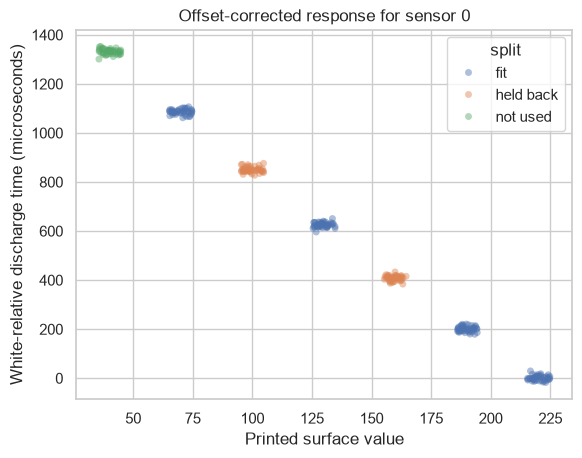

In [6]:
sns.stripplot(
    data=selected, x="surface_value", y="offset_corrected_us",
    hue="split", jitter=0.16, alpha=0.45, native_scale=True,
)
plt.title(f"Offset-corrected response for sensor {SELECTED_SENSOR}")
plt.xlabel("Printed surface value")
plt.ylabel("White-relative discharge time (microseconds)")
plt.show()


## 6. Fit and report the straight-line equation

The fit uses one mean response per selected surface condition:

$$\hat{y}=mx+c$$

Here $m$ is the gain or slope and $c$ is the intercept. `np.polyfit`
returns them in the order **slope, then intercept**.


In [7]:
response_summary = (
    selected.loc[selected["split"] != "not used"]
    .groupby(["surface_value", "split"], as_index=False)
    .agg(measured_us=("offset_corrected_us", "mean"),
         repeat_sd_us=("offset_corrected_us", "std"))
)
fitting_rows = response_summary.loc[response_summary["split"] == "fit"]
slope, intercept = np.polyfit(fitting_rows["surface_value"], fitting_rows["measured_us"], 1)
response_summary["predicted_us"] = slope * response_summary["surface_value"] + intercept
response_summary["residual_us"] = response_summary["measured_us"] - response_summary["predicted_us"]
coefficients = pd.DataFrame([
    {"coefficient": "gain", "symbol": "m", "value": slope,
     "units": "microseconds per surface-value unit"},
    {"coefficient": "intercept", "symbol": "c", "value": intercept,
     "units": "microseconds"},
])
print(f"Fitted equation: y_hat = {slope:.3f} * surface_value {intercept:+.3f}")
coefficients


Fitted equation: y_hat = -7.239 * surface_value +1581.905


,coefficient,symbol,value,units
0,gain,m,-7.239061,microseconds per surface-value unit
1,intercept,c,1581.905137,microseconds


## 7. Plot the fit and residuals across all retained conditions


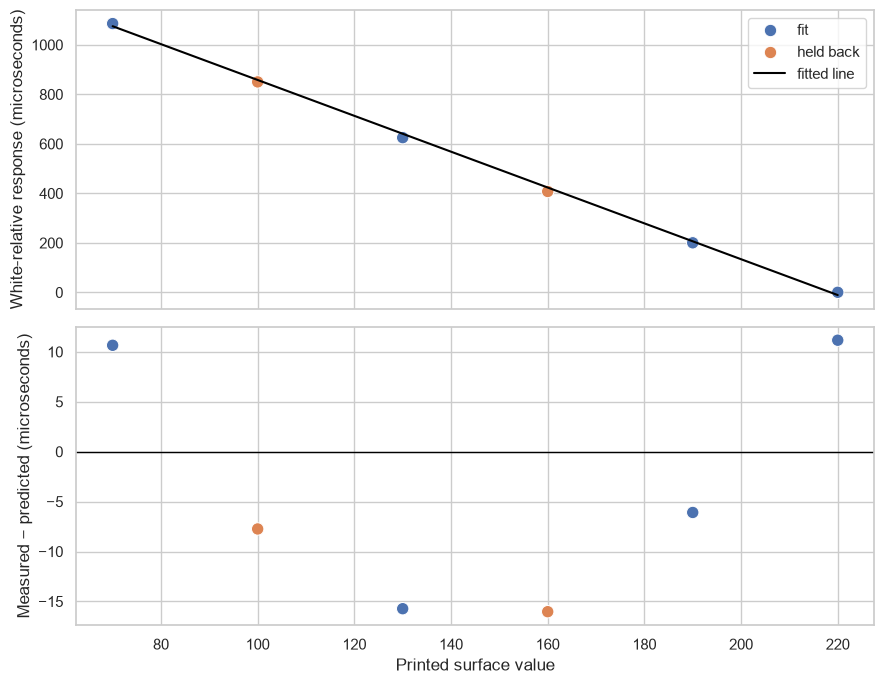

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
sns.scatterplot(data=response_summary, x="surface_value", y="measured_us", hue="split", s=80, ax=axes[0])
ordered = response_summary.sort_values("surface_value")
axes[0].plot(ordered["surface_value"], ordered["predicted_us"], color="black", label="fitted line")
axes[0].set(ylabel="White-relative response (microseconds)")
axes[0].legend()
sns.scatterplot(data=response_summary, x="surface_value", y="residual_us", hue="split", s=80, ax=axes[1], legend=False)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(xlabel="Printed surface value", ylabel="Measured − predicted (microseconds)")
plt.tight_layout()
plt.show()


## 8. Inspect the held-back predictions


In [9]:
held_back_results = response_summary.loc[
    response_summary["split"] == "held back",
    ["surface_value", "measured_us", "predicted_us", "residual_us"],
]
held_back_results


,surface_value,measured_us,predicted_us,residual_us
1,100,850.256816,857.999001,-7.742186
3,160,407.625563,423.655320,-16.029757


## What to notice

- Is the fitted region supported by your saturation evidence?
- Do held-back errors look small relative to repeated variation?
- Do residuals curve systematically outside the local fitting region?
- Change `SELECTED_SENSOR` and its white reference to repeat all five channels.
